In [19]:
import sys
sys.path.append('../')

import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
from sympy import symbols
import utils_2Q_gate_zp as ut
ut.set_fig_font() ### Set various sizes in plotting
import scipy as sp
import pandas as pd
import itertools
# Reset to the default Matplotlib color cycle
plt.rcParams['axes.prop_cycle'] = plt.rcParamsDefault['axes.prop_cycle']

In [20]:
# params = np.array([
# ])
# f_200 = np.array([   
# ])
# df = pd.DataFrame(data=np.hstack((params, f_200.reshape(-1,1))),
#                   columns=['tg', 'drive_amp', 'detune', 'f_200'])
# df_detune = df.sort_values(by='tg')
# df_detune

# df_full.to_csv('data/npz/cz_pulse_v0.txt', sep=',', index=False, header=True)
# df_sorted.to_csv('data/npz/cz_pulse_detune_-0.05_-0.1.txt', sep=',', index=False, header=True)

df_v0= pd.read_csv('data/npz/cz_pulse_v0.txt')
df_neig= pd.read_csv('data/npz/cz_pulse_neighbor.txt')
df_detune= pd.read_csv('data/npz/cz_pulse_detune_-0.05_-0.1.txt')

cz_se= pd.read_csv('../figure/data/data_cz_3ncut_truc1=300_select.txt')
cz= pd.read_csv('data/data_cz_3ncut_truc1=300.txt')
tg_list = np.array([20, 65, 110, 155, 199])


In [21]:
f_npz = np.array([
[-0.2884005207005171, -1.2184435329527927, -1.9977868994875263, -2.6780230587919447, -2.911239016002514] ,
[-0.3948604077148842, -1.1291246947286284, -2.3483432660772046, -3.3969340994219177, -4.301803771997159] ,
[-0.39516535204861314, -1.1216993949292018, -2.350804076071513, -3.3932026733119307, -4.307048906008804] ,
[-0.5344734647100349, -1.1129330076435384, -2.3444795218573296, -3.392104299846341, -4.307122263855342] ,
[-0.5560238788435214, -1.1175199528598592, -2.3432138419092943, -3.3922609191390314, -4.306166644884673] ,
[-0.5539023510812817, -1.1164661168175527, -2.3407544357411885, -3.392084167909524, -4.305636862915254] ,
[-0.5213165556284403, -1.1140405158120221, -2.344922500969644, -3.3918255166017466, -4.305541991045556] ,
[-0.5845463947347512, -1.109925826677288, -2.3242127236924888, -3.392240071115177, -4.305125552488127] ,
[-0.5798028302081641, -1.11170949530076, -2.326288114928186, -3.392141623528959, -4.30479631347605] ,
[-0.5782394206429502, -1.1119759016144335, -2.3275311208335885, -3.391788567537528, -4.304019204693071] ,
[-0.5809801236947378, -1.1123827401641473, -2.3282965046869197, -3.391016403478912, -4.30251445990453] ,
[-0.5788896392163535, -1.1140440360732697, -2.330016637584638, -3.3909843832123827, -4.3025029200036595] ,
[-0.5968247125591561, -1.115518420776858, -2.327229202478406, -3.3875068770441192, -4.30255488524026] ,
[-0.6131413097246448, -1.1145209393409468, -2.318863284430055, -3.3872555137709512, -4.302806415451103] ,
[-0.6132671292337495, -1.114373772944328, -2.3177008751725885, -3.3872036220065778, -4.302803624421084] ,
[-0.6137116767352062, -1.1143363728922002, -2.3177149543653734, -3.3871931609748183, -4.302811928410482] ,
[-0.614307958283628, -1.114490257576917, -2.3172540703883446, -3.3870885369593653, -4.302806103965225] ,
[-0.6140841660118191, -1.1147799561740765, -2.317591252381764, -3.3870725905408468, -4.302670607599391] ,
[-0.6146210103959878, -1.1148126308700828, -2.3176009352143248, -3.387068922282195, -4.302661250453879] ,
])
n_truc_list = [100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850, 900, 950, 1000]


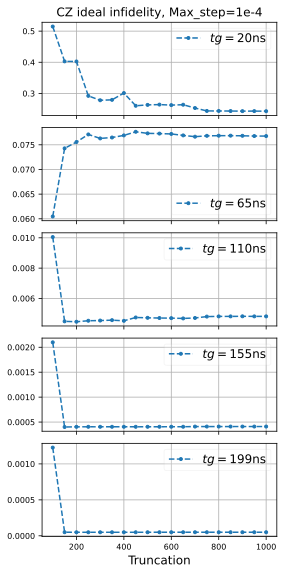

In [22]:
fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i in range(5):
    ax[i].plot(n_truc_list, 10**f_npz[:,i], '.--', label=fr'$tg = {tg_list[i]:.0f}$ns')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=12)
    legend.get_frame().set_alpha(0.2)
    # ax[i].set_ylabel(fr'$t_g = {params[:,0][i]:.0f}$ns')
ax[4].set_xlabel('Truncation', fontsize=12)
ax[0].set_title(fr'CZ ideal infidelity, Max_step=1e-4', fontsize=12)
plt.tight_layout()

In [23]:

f_ideal_1e3 = np.array([
-0.39516535, -1.12169939, -2.35080408, -3.39320267, -4.30704891
])
f_ideal_1e4 = np.array([
-0.39511517, -1.12103761, -2.35201248, -3.38863046 ,
-4.29566507 ,
])
f_ideal_1e5 = np.array([
-0.39513672, -1.12117493, -2.35226297, -3.38923867 ,
-4.29661235 ,
])
f_ideal_3e4 = np.array([
-0.39511297, -1.12099394, -2.35209253, -3.38824095 ,
-4.29380043 ,
])

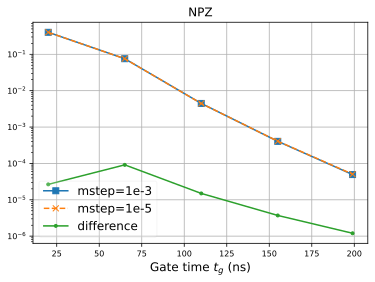

In [24]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tg_list, 10**f_ideal_1e3, 's-',  label=r'mstep=1e-3')
ax.plot(tg_list, 10**f_ideal_1e5, 'x--',  label=r'mstep=1e-5')
ax.plot(tg_list, np.abs(10**f_ideal_1e5 - 10**f_ideal_1e3), '.-',  label=r'difference')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'NPZ', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

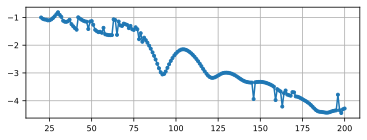

In [25]:
fig, ax = plt.subplots(figsize=(6,2))
plt.plot(df_v0['tg'], df_v0['f_200'], '.-')
plt.grid()

In [26]:
# df = pd.DataFrame(data=np.hstack((param_optimized, f_200.reshape(-1,1), f_1000.reshape(-1,1))),
#                   columns=['tg', 'drive_amp', 'detune', 'f_200', 'f_1000'])
# df_reversed = df.iloc[::-1].reset_index(drop=True)
# df_reversed.to_csv('data/npz/cz_pulse_add.txt', sep=',', index=False, header=True)
# df_reversed

In [27]:
f_ideal_2000 = np.array([
-0.61470142, -0.59571532, -0.55723160, -0.50173075 ,
-0.30985390, -0.30981095, -0.31177707, -0.31734456 ,
-0.32286039, -0.32877422, -0.33403494, -0.36750248 ,
-0.38957667, -0.37851999, -0.28676635, -0.32026067 ,
-0.35397279, -0.38149243, -0.43148265, -0.56318490 ,
-0.68498544, -0.77855447, -0.85330658, -0.93767901 ,
-1.00708168, -1.06188074, -1.09833857, -1.11863042 ,
-1.12517017, -1.11967633, -1.14159672, -1.12615616 ,
-1.10253216, -1.07905661, -1.05517729, -1.03245587 ,
-1.00849267, -0.98771753, -0.96942289, -0.97255198 ,
-0.99469440, -1.01581006, -1.03898755, -1.06295230 ,
-1.08828250, -1.11486518, -1.14029818, -1.16648401 ,
-1.19212398, -1.21651779, -1.24011958, -1.26218773 ,
-1.28305395, -1.30195352, -1.31885794, -1.33345507 ,
-1.33626276, -1.40838130, -1.47803892, -1.55223816 ,
-1.63030958, -1.71418808, -1.80241860, -1.89647977 ,
-1.99920339, -2.10467834, -2.23402439, -2.35028892 ,
-2.47254130, -2.61356945, -2.74414191, -2.84721637 ,
-2.89185675, -2.85995024, -2.78510500, -2.68034009 ,
-2.56865437, -2.47002395, -2.37804554, -2.29237896 ,
-2.23327562, -2.17566110, -2.13040581, -2.10544311 ,
-2.09854822, -2.10652974, -2.12814569, -2.16110103 ,
-2.20793345, -2.26092615, -2.31699945, -2.38355104 ,
-2.46308360, -2.54044588, -2.62880757, -2.71828224 ,
-2.81459145, -2.90276485, -2.99253311, -3.05458236 ,
-3.10627182, -3.13981809, -3.14750449, -3.13636061 ,
-3.11190571, -3.07840837, -3.04661154, -3.01603887 ,
-2.99451056, -2.98482353, -2.98474961, -2.98869476 ,
-3.00402789, -3.02037683, -3.04878384, -3.07741645 ,
-3.11955966, -3.15994382, -3.20242498, -3.23671181 ,
-3.27218521, -3.29605545, -3.31612305, -3.32836948 ,
-3.33671505, -3.33956017, -3.33620284, -3.32648310 ,
-3.31893891, -3.31083739, -3.31223411, -3.31454057 ,
-3.32259296, -3.34359944, -3.36326306, -3.38565618 ,
-3.41256092, -3.44626879, -3.48664502, -3.52840493 ,
-3.57601899, -3.61897848, -3.65855859, -3.69104968 ,
-3.72029909, -3.74647071, -3.77154072, -3.79382776 ,
-3.81153923, -3.82121270, -3.83073411, -3.83457709 ,
-3.84979206, -3.87206066, -3.90277879, -3.93629463 ,
-3.97506584, -4.00988158, -4.05137074, -4.09616455 ,
-4.15114524, -4.20590937, -4.27230093, -4.32274571 ,
-4.36787339, -4.38093152, -4.39163928, -4.40293833 ,
-4.41265086, -4.42025502, -4.42219546, -4.40349218 ,
-4.38822727, -4.36074988, -4.34808835, -4.34524099 ,
-4.33858270, -4.33334898, -4.32052834, -4.29784033 ,
])

f_ideal_1000 = np.array([
-0.61462101, -0.59601337, -0.55798623, -0.50294221 ,
-0.30985916, -0.30982795, -0.31179452, -0.31736318 ,
-0.32287810, -0.32879995, -0.33406318, -0.36941227 ,
-0.39185500, -0.38284197, -0.29378217, -0.32845284 ,
-0.36342695, -0.39200734, -0.44358466, -0.57761497 ,
-0.69965804, -0.79319646, -0.86789409, -0.95156875 ,
-1.01974248, -1.07452869, -1.11018175, -1.12884598 ,
-1.13335279, -1.12536677, -1.14666353, -1.13018369 ,
-1.10524011, -1.08100144, -1.05636407, -1.03314346 ,
-1.00882727, -0.98779434, -0.96922385, -0.97169041 ,
-0.99364501, -1.01495111, -1.03836484, -1.06255553 ,
-1.08808782, -1.11481263, -1.14040500, -1.16672831 ,
-1.19243087, -1.21685763, -1.24052157, -1.26257799 ,
-1.28342836, -1.30232581, -1.31921655, -1.33376800 ,
-1.33891079, -1.41057710, -1.48032723, -1.55437950 ,
-1.63226285, -1.71613832, -1.80445397, -1.89850782 ,
-2.00133934, -2.10684967, -2.23608081, -2.35223970 ,
-2.47340389, -2.61311209, -2.74105332, -2.84050338 ,
-2.88199226, -2.84873769, -2.77460061, -2.67166178 ,
-2.56164716, -2.46457031, -2.37381900, -2.28911655 ,
-2.23086286, -2.17400923, -2.12933991, -2.10483953 ,
-2.09842458, -2.10666885, -2.12846768, -2.16154579 ,
-2.20843561, -2.26147374, -2.31760094, -2.38416547 ,
-2.46370724, -2.54119984, -2.62952040, -2.71910200 ,
-2.81547140, -2.90367462, -2.99360789, -3.05569949 ,
-3.10759419, -3.14138244, -3.14931936, -3.13786739 ,
-3.11345750, -3.08002673, -3.04833007, -3.01734138 ,
-2.99602704, -2.98584301, -2.98560226, -2.99000786 ,
-3.00490826, -3.02174160, -3.04986747, -3.07861039 ,
-3.12057980, -3.16144271, -3.20371291, -3.23832487 ,
-3.27390397, -3.29789922, -3.31746986, -3.32932280 ,
-3.33819939, -3.34057507, -3.33746016, -3.32808515 ,
-3.32043748, -3.31199788, -3.31346215, -3.31616923 ,
-3.32469565, -3.34450867, -3.36440613, -3.38706892 ,
-3.41390811, -3.44731401, -3.48757570, -3.53028524 ,
-3.57735556, -3.62048026, -3.66002512, -3.69288985 ,
-3.72264490, -3.74910357, -3.77443210, -3.79655884 ,
-3.81448811, -3.82460844, -3.83313881, -3.83785253 ,
-3.85256948, -3.87502841, -3.90558723, -3.93988622 ,
-3.97752246, -4.01307161, -4.05394553, -4.09915123 ,
-4.15401505, -4.21080010, -4.27628336, -4.32922790 ,
-4.37264263, -4.38729344, -4.39739668, -4.40648571 ,
-4.41677341, -4.42592360, -4.42595222, -4.40778542 ,
-4.38922604, -4.36578141, -4.35297723, -4.34844312 ,
-4.34285598, -4.33731082, -4.32545245, -4.30266125 ,
])

In [33]:
f_200_m0 = np.array([
-0.39305341, -1.09992334, -2.32924629, -2.64112870 ,
-2.44756693 ,
])
f_1000_m0 = np.array([
-0.61319797, -1.10636088, -2.33448971, -3.10155043 ,
-3.38196108 ,
])
f_200_m0_v2 = np.array([
-0.39305341, -0.31188240, -0.43343626, -0.79723923 ,
-1.07365971, -1.11528052, -0.97914566, -1.02656829 ,
-1.17042588, -1.28292824, -1.68798285, -2.34995043 ,
-2.91864232, -2.29662552, -2.06852485, -2.32924629 ,
-2.74896101, -2.85434978, -2.69561409, -2.71555557 ,
-2.72576374, -2.75602744, -2.65590219, -2.64214759 ,
-2.60023706, -2.60421205, -2.60046587, -2.53487540 ,
-2.48450929, -2.50588336 ,
])
f_1000_m0_v2 = np.array([
-0.61319797, -0.31175696, -0.39076839, -0.44354222 ,
-1.01507469, -1.13589864, -0.99619945, -1.03183473 ,
-1.18130664, -1.30096445, -1.66273450, -2.29068531 ,
-2.85105378, -2.29670331, -2.07553567, -2.33448971 ,
-2.83494156, -3.05412392, -2.90043604, -2.98880819 ,
-3.10209489, -3.14166846, -3.10375074, -3.24471479 ,
-3.29258332, -3.34014655, -3.36468634, -3.65605867 ,
-3.22068724, -3.43624942 ,
])

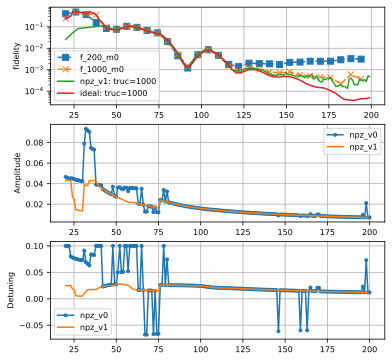

In [35]:
fig, ax = plt.subplots(3,1,figsize=(6,6))

ax[0].plot(df_neig['tg'][0::6], 10**f_200_m0_v2, 's--', label='f_200_m0')
ax[0].plot(df_neig['tg'][0::6], 10**f_1000_m0_v2, 'x--', label='f_1000_m0')

ax[0].plot(df_neig['tg'], 10**df_neig['f_1000'], '-', label='npz_v1: truc=1000')
ax[0].plot(df_neig['tg'], 10**f_ideal_1000, '-', label='ideal: truc=1000')
# ax[0].plot(df_neig['tg'], 10**f_ideal_2000, '--', label='ideal: truc=2000')
# ax[0].plot(cz['tg'], 10**cz['f_1000_False'], '-', label='cz: truc=1000')
# ax[0].plot(param_optimized[:,0], 10**f_1000, 'x--', label='truc=1000')
# ax[0].plot(param_optimized_r[:,0], 10**f_200_r, '.-', label='r:truc=200')
# ax[0].plot(df_neig['tg'], 10**df_neig['f_1000'], '.', label='neig: truc=1000', alpha=0.9)
# ax[0].plot(param_200[:,0], 10**f_1000, '.', label='truc=1000', alpha=0.9)

# ax[0].plot(df_v0['tg'], 10**df_v0['f_200'], '.-', label='npz_v0: truc=200')
# ax[0].plot(df_neig['tg'], 10**df_neig['f_200'], '--', label='npz_v1: truc=200')
# ax[0].plot(cz['tg'], 10**cz['f_200_select'], '--', label='cz: truc=200')
# ax[0].plot(param_optimized[:,0], 10**f_200, 's--', label='truc=200')
ax[0].set_ylabel('fidelity')
ax[0].set_yscale('log')
ax[0].legend()

ax[1].plot(df_v0['tg'], df_v0['drive_amp'], '.-', label='npz_v0')
ax[1].plot(df_neig['tg'], df_neig['drive_amp'], '-', label='npz_v1')
# ax[1].plot(cz['tg'], cz['drive_amp'], '-', label='cz')
# ax[1].plot(param_optimized[:,0], param_optimized[:,1], '.-')
# ax[1].plot(param_optimized_r[:,0], param_optimized_r[:,1], '.-')
ax[1].set_ylabel('Amplitude')

ax[2].plot(df_v0['tg'], df_v0['detune'], '.-', label='npz_v0')
ax[2].plot(df_neig['tg'], df_neig['detune'], '-', label='npz_v1')
# ax[2].plot(cz['tg'], cz['detune'], '-', label='cz')
# ax[2].plot(param_optimized[:,0], param_optimized[:,2], '.-')
# ax[2].plot(param_optimized_r[:,0], param_optimized_r[:,2], '.-')
ax[2].set_ylabel('Detuning')
for a in ax:
    a.grid()
    a.legend()
    # a.set_xlim(20, 60)
# ax[0].set_ylim(2e-2, 1e0)    
# ax[0].set_title('x0 from neighboring tg v3')
# ax[1].set_ylim(0.007, 0.0095)    
# ax[2].set_ylim(0.01, 0.025)    

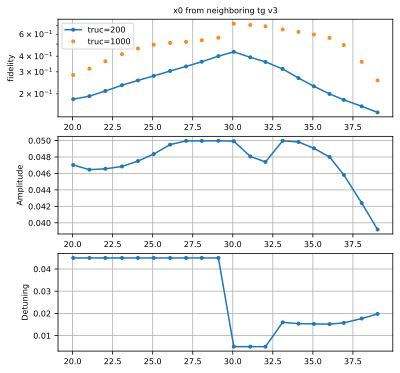

In [7]:
fig, ax = plt.subplots(3,1,figsize=(6,6))
ax[0].set_title('x0 from neighboring tg v3')
ax[0].plot(param_200[:,0], 10**f_200, '.-', label='truc=200')
ax[0].plot(param_200[:,0], 10**f_1000, '.', label='truc=1000', alpha=0.9)
ax[0].set_ylabel('fidelity')
ax[0].set_yscale('log')
ax[0].legend()

ax[1].plot(param_200[:,0], param_200[:,1], '.-')
ax[1].set_ylabel('Amplitude')

ax[2].plot(param_200[:,0], param_200[:,2], '.-')
ax[2].set_ylabel('Detuning')
for a in ax:
    a.grid()

In [4]:
f_v0 = np.array([
[-0.22140583928033802, -0.4042992836580386, -0.38048559261848014, -0.25415632900411045, -1.0885545618900963, -1.1397456632143508, -0.17178008130365133, -0.14048211613099088, -1.3176525508667132, -1.4387743744152228, -0.42833489729249985, -2.129887297791659, -2.569302074268763, -2.319071819429386, -2.1068732488033213, -2.325811993120206, -2.8241781454509165, -3.154338339514013, -2.997477676770211, -3.0528396005506377, -3.279768183022692, -3.9230163845877795, -3.333344635813918, -3.492179504079611, -3.7276702347517605, -3.694886977451378, -3.9794756648958693, -4.276484582998004, -4.415817449156851, -4.355371557470215, -4.277501892600658] ,
[-0.21961552294481784, -0.4058088650303064, -0.33053615715746715, -0.24339851946348748, -1.019380171820108, -1.1464351205837149, -0.1826017701049461, -0.14531714738700804, -1.3171834978303842, -1.4381715460720494, -0.4416114064117939, -2.235949373407873, -2.881476294941248, -2.375009848953589, -2.098313608714436, -2.3166765633667996, -2.815704488782356, -3.1493598270800174, -2.995464915947434, -3.050015514505104, -3.274144561367379, -3.9237144047474866, -3.3283602165799184, -3.487598268364873, -3.723347543943965, -3.6942980391105613, -3.977196029613066, -4.2734500958991335, -4.411631488126671, -4.353148964393151, -4.276035896426003] ,
[-0.21915923349460092, -0.40967114847995345, -0.33609818120077073, -0.24024013195874314, -1.007366087060195, -1.1415628960829611, -0.18028667502592588, -0.1472756192975686, -1.3170082793935312, -1.437938300278989, -0.46441268653213086, -2.235671656058528, -2.891697646468711, -2.3780446778456317, -2.0983088630023463, -2.3167054184005935, -2.815589160915196, -3.147601204509452, -2.9936120509023776, -3.0487553540874996, -3.272934813833775, -3.9251682986359957, -3.3273893059301276, -3.4863266722604735, -3.720687962171578, -3.692834068210069, -3.9728412357186995, -4.265669729801684, -4.400935334122678, -4.346453132383692, -4.270563401119897] ,
[-0.21907457178319267, -0.4098846421171799, -0.3462760750378626, -0.24061733256525566, -1.0066709379168621, -1.141327947473188, -0.17977796890719927, -0.14679147047831195, -1.316924222165654, -1.4378606456942449, -0.462092699786399, -2.233751392944286, -2.8913974190954232, -2.3792289687578707, -2.0984362902820726, -2.31611057597419, -2.8149765633117676, -3.147586664368928, -2.993903428950462, -3.0487962490853295, -3.272706476001417, -3.924680363633159, -3.327260482147087, -3.486393117110736, -3.7212956850070023, -3.6932676952510715, -3.9738293006769627, -4.268072511016354, -4.405233092303032, -4.348953524608262, -4.272303253447396] ,
])
f_detune = np.array([
[-3.0114163126121687, -2.618707638868861, -3.3158043821725522, -3.4123950253952215, -3.658431663932262, -2.853530889150149, -3.980417285140459, -3.014859142081049, -4.03253511632453, -3.0821826583383203, -3.9313652234564826, -2.166258534679407, -4.076942479140673, -4.248094328957428, -4.317828892877567, -4.335005214074846, -4.338555316434584, -4.331849396415948, -2.166205788187525, -4.242068028634878, -4.3581505392316195, -4.697846068049656, -4.7474783932440126, -4.491640499855651, -4.52929805103162] ,
[-3.0098933331796514, -2.7612558226495776, -3.31448214270295, -3.41118929649636, -3.6564136590009984, -3.05807704886465, -3.9804995096337548, -3.30294057537712, -4.0344963971242995, -3.3908956030321593, -3.933535032138978, -2.1612921141794623, -4.077592792313475, -4.2499950131144155, -4.319537344300744, -4.335285420920167, -4.3387940024337714, -4.333952778061786, -2.1618794562295114, -4.24239972544187, -4.355664704445066, -4.694643148805874, -4.748082609569556, -4.4953506547225395, -4.525170565287811] ,
[-3.0085260446119277, -2.7372357046259457, -3.3136673365098535, -3.410355450198115, -3.6545146480396684, -3.021565680863311, -3.9816220373731968, -3.2469665087899466, -4.037374741224356, -3.3291039556463673, -3.9360377606937886, -2.162843422793242, -4.077586936451681, -4.2512413786820265, -4.319743997621098, -4.33346937854192, -4.337240586682846, -4.336118055379173, -2.1638162822142433, -4.241036243377804, -4.348395559785142, -4.682188051486316, -4.740879597286351, -4.499140777102846, -4.511521255019058] ,
[-3.008664493364196, -2.737438959085249, -3.313705644820066, -3.4105191387276657, -3.655147032199676, -3.0221460615333178, -3.981336676656362, -3.2483254989215453, -4.036213235515556, -3.3316909481648764, -3.934888492761777, -2.1613370254603805, -4.07748091276951, -4.250624834305379, -4.319690926974582, -4.334223538982575, -4.337702172303715, -4.335607831360731, -2.1619982837226104, -4.2414455137232885, -4.350960885783712, -4.686743865599866, -4.743131843317241, -4.498478361873581, -4.515419530860775] ,
])

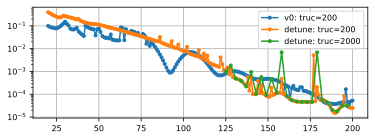

In [5]:
tg_list = np.arange(105,180)[0::3].tolist()
fig, ax = plt.subplots(figsize=(6,2))
plt.plot(df_v0['tg'], 10**df_v0['f_200'], '.-', label='v0: truc=200')
plt.plot(df_detune['tg'], 10**df_detune['f_200'], '.-', label='detune: truc=200')
# plt.plot(df_v0['tg'][tg_list], 10**df_detune['f_200'][tg_list], '.-', label='truc=200')
plt.plot(df_v0['tg'][tg_list], 10**f_detune[-1], '.-', label='detune: truc=2000')
# plt.title('Pulse_detune')
plt.yscale('log')
plt.grid()
plt.legend()

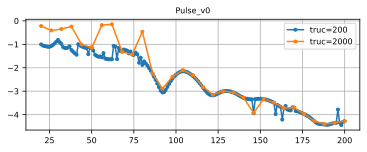

In [7]:
fig, ax = plt.subplots(figsize=(6,2))
plt.plot(df_v0['tg'], df_v0['f_200'], '.-', label='truc=200')
# plt.plot(df_v0['tg'][0::6],fidelity_list[0], '.-', label='truc=500')
plt.plot(df_v0['tg'][0::6],f_v0[-1], '.-', label='truc=2000')
plt.title('Pulse_v0')
plt.grid()
plt.legend()

In [8]:
f_ideal_1000 = np.array([
-0.74615650, -0.35735157, -0.40215531, -0.56178381 ,
-0.95811679, -1.15564116, -1.03580528, -1.05336740 ,
-1.20356508, -1.32266091, -1.60649343, -2.21255395 ,
-2.86482092, -2.40556149, -2.16238642, -2.38798190 ,
-2.82838483, -3.00699633, -2.94030583, -3.06534253 ,
-3.24019506, -3.25350188, -3.30892131, -3.52221173 ,
-3.72987194, -3.85810978, -4.09601386, -4.33899580 ,
-4.26563472, -4.12619435, -3.94939514 ,
])
f_ideal_1000_npz = np.array([
-0.72049574, -0.33201747, -0.41058575, -0.60643456 ,
-1.01800388, -1.14577047, -1.00875814, -1.03728788 ,
-1.18763931, -1.31333139, -1.59989737, -2.16729271 ,
-2.65364118, -2.32227948, -2.09225387, -2.28806567 ,
-2.71234580, -3.00976953, -2.91097220, -2.96031838 ,
-3.11780820, -3.16594948, -3.16870582, -3.28996270 ,
-3.41174452, -3.49669505, -3.56362582, -3.66449257 ,
-3.72243185, -3.69454265, -3.68364552 ,
])

f_200_tg_0 = np.array([
-1.00355878, -1.24333334, -1.4473779, -1.32371541 ,
-3.05337003, -2.35115076, -3.0037915, -3.34374839 ,
-3.72748311, -4.27900147, -4.27885363 ,
])

f_200_tg_1 = np.array([
-1.07245002, -1.47715479, -1.17681139, -1.64377048 ,
-2.46342492, -2.85278414, -3.05375236, -3.33402596 ,
-3.83755769, -4.41682576 ,
])
f_200_tg_2 = np.array([
-0.97809998, -1.13451877, -1.64766993, -2.2594689 ,
-2.1480107, -3.17578914, -3.28063401, -3.49173382 ,
-3.97910147, -4.35661976 ,
])

f_200_tg_0_bound = np.array([
-1.06064067, -1.5978517, -2.56850942, -1.83120878 ,
-3.05319374, -2.81797385, -3.00280991, -3.34243314 ,
-3.60805005, -4.28042006, -3.89994672 ,
])
f_200_tg_0_mutation = np.array([
-1.00355119, -0.90135328, -1.55282476, -1.32473193 ,
-3.05336354, -2.35154197, -3.00361287, -3.34536466 ,
-3.72859765, -4.28029589, -3.9009206 ,
])
f_200_tg_0_tol = np.array([
-1.00384989, -0.9841791, -1.55494839, -1.42932378 ,
-3.05417588, -2.35227798, -3.00387987, -3.34546797 ,
-3.72885583, -4.2801667, -4.27881127 ,
])

f_1500_v0 = np.array([
-0.21915923, -0.40967115, -0.33609818, -0.24024013 ,
-1.00736609, -1.14156290, -0.18028668, -0.14727562 ,
-1.31700828, -1.43793830, -0.46441269, -2.23567166 ,
-2.89169765, -2.37804468, -2.09830886, -2.31670542 ,
-2.81558916, -3.14760120, -2.99361205, -3.04875535 ,
-3.27293481, -3.92516830, -3.32738931, -3.48632667 ,
-3.72068796, -3.69283407, -3.97284124, -4.26566973 ,
-4.40093533, -4.34645313, -4.27056340 ,
])


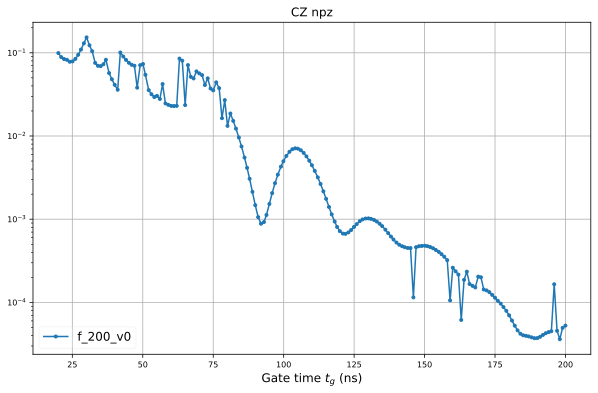

In [9]:

fig, ax = plt.subplots(figsize=(10,6))
# ax.plot(cz_se['tg'], 10**f_ideal_1000, '.-',  label=r'f_1000_old')
# ax.plot(cz_se['tg'], 10**f_ideal_1000_npz, '.--',  label=r'f_1000_npz')
# ax.plot(cz_se['tg'][0::3], 10**f_200_tg_0, 'bs',  label=r'f_200_v1')
# ax.plot(cz_se['tg'][1::3], 10**f_200_tg_1, 'bs')
# ax.plot(cz_se['tg'][2::3], 10**f_200_tg_2, 'bs')
plt.plot(df_v0['tg'], 10**df_v0['f_200'], '.-', label=r'f_200_v0')
# plt.plot(df_detune['tg'], 10**df_detune['f_200'], '.-', label=r'f_200_detune')
# plt.plot(df_v0[0::6]['tg'], 10**f_ideal_1500, '.-', label=r'f_1500_v0')

# ax.plot(cz_se['tg'][0::3], 10**f_200_tg_0_bound, '.-',  label=r'f_200_tg_0_bound')
# ax.plot(cz_se['tg'][0::3], 10**f_200_tg_0_mutation, 'x-',  label=r'f_200_tg_0_mutation')
# ax.plot(cz_se['tg'][0::3], 10**f_200_tg_0_tol, '+-',  label=r'f_200_tg_0_tol')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'CZ npz', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

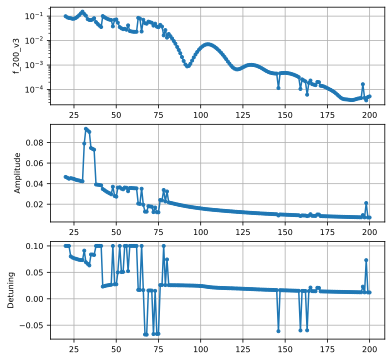

In [11]:
fig, ax = plt.subplots(3,1,figsize=(6,6))

ax[0].plot(df_v0['tg'], 10**df_v0['f_200'], '.-')
ax[0].set_ylabel('f_200_v3')
ax[0].set_yscale('log')

ax[1].plot(df_v0['tg'], df_v0['drive_amp'], '.-')
ax[1].set_ylabel('Amplitude')

ax[2].plot(df_v0['tg'], df_v0['detune'], '.-')
ax[2].set_ylabel('Detuning')
for a in ax:
    a.grid()

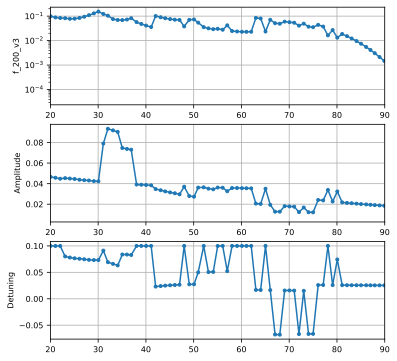

In [20]:
fig, ax = plt.subplots(3,1,figsize=(6,6))

ax[0].plot(df_v0['tg'], 10**df_v0['f_200'], '.-')
ax[0].set_ylabel('f_200_v3')
ax[0].set_yscale('log')

ax[1].plot(df_v0['tg'], df_v0['drive_amp'], '.-')
ax[1].set_ylabel('Amplitude')

ax[2].plot(df_v0['tg'], df_v0['detune'], '.-')
ax[2].set_ylabel('Detuning')
for a in ax:
    a.grid()
    a.set_xlim(20, 90)
# ax[0].set_ylim(2e-2, 2e-1)    
# ax[2].set_ylim(0, 0.11)    

In [13]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

### CZ Infidelity convergence on truncation

max_step=1e-4

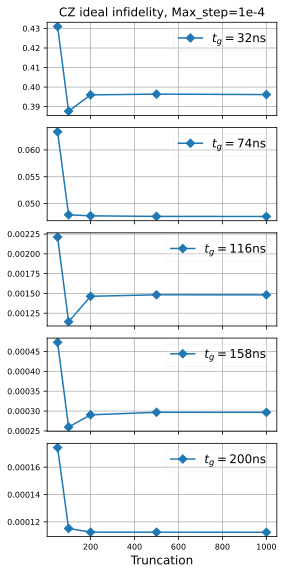

In [ ]:
fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i in range(5):
    ax[i].plot(truc, 10**f_ideal_1e4[i], 'D-', label=fr'$t_g = {tg_list[i]:.0f}$ns')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=12)
    legend.get_frame().set_alpha(0.2)
    # ax[i].set_ylabel(fr'$t_g = {params[:,0][i]:.0f}$ns')
ax[4].set_xlabel('Truncation', fontsize=12)
ax[0].set_title(fr'CZ ideal infidelity, Max_step=1e-4', fontsize=12)
plt.tight_layout()